In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import networkx as nx

# ==========================================
# 1. ERDŐS-RÉNYI GRAPH & PARAMETERS
# ==========================================
N = 20        # 20 agents
p_er = 0.35   # Erdős–Rényi edge probability
dt = 0.05     # Step size
tol = 0.01    # Convergence tolerance
max_steps = 120

def generate_connected_er(N, p):
    while True:
        G = nx.erdos_renyi_graph(N, p)
        if nx.is_connected(G):
            return G

G = generate_connected_er(N, p_er)
A = nx.adjacency_matrix(G).toarray().astype(float)
D = np.diag(A.sum(axis=1))
L = D - A

# ==========================================
# 2. DEFINING "TARUN" OFFSETS (RIGHT ALIGNED R)
# ==========================================
def get_letter_offsets():
    # Letter 'T'
    t_top_x = np.linspace(-0.8, 0.8, 12)
    t_top_y = np.full(12, 1.0)
    t_stem_x = np.zeros(8)
    t_stem_y = np.linspace(0.75, -1.0, 8)
    r_T = np.vstack([np.column_stack([t_top_x, t_top_y]),
                     np.column_stack([t_stem_x, t_stem_y])])

    # Letter 'A'
    a_left_x = np.linspace(-0.7, 0.0, 7)
    a_left_y = np.linspace(-1.0, 1.0, 7)
    a_right_x = np.linspace(0.0, 0.7, 8)[1:]
    a_right_y = np.linspace(1.0, -1.0, 8)[1:]
    a_cross_x = np.linspace(-0.35, 0.35, 6)
    a_cross_y = np.full(6, -0.1)
    r_A = np.vstack([np.column_stack([a_left_x, a_left_y]),
                     np.column_stack([a_right_x, a_right_y]),
                     np.column_stack([a_cross_x, a_cross_y])])

    # 3. Letter 'R' (20 points - Custom Piecewise Definition)
    stem_R = np.column_stack([np.full(8, -3.0), np.linspace(-5, 5, 8)])
    top_R = np.column_stack([np.linspace(-2, 2, 3), np.full(3, 5.0)])
    right_R = np.column_stack([np.full(2, 2.0), np.linspace(1.6, 3.3, 2)])
    mid_R = np.column_stack([np.linspace(-1, 1, 2), np.full(2, 0.0)])
    diag_R = np.column_stack([np.linspace(-1, 3, 5), np.linspace(-1, -5, 5)])

    # Stack segments and scale to match [-1, 1] frame
    r_R = np.vstack([stem_R, top_R, right_R, mid_R, diag_R]) / 5.0

    # Letter 'U'
    u_left_x = np.full(6, -0.7)
    u_left_y = np.linspace(1.0, -0.1, 6)
    theta_u = np.linspace(np.pi, 2*np.pi, 10)[1:-1]
    u_curve_x = 0.7 * np.cos(theta_u)
    u_curve_y = -0.3 + 0.7 * np.sin(theta_u)
    u_right_x = np.full(6, 0.7)
    u_right_y = np.linspace(-0.1, 1.0, 6)
    r_U = np.vstack([np.column_stack([u_left_x, u_left_y]),
                     np.column_stack([u_curve_x, u_curve_y]),
                     np.column_stack([u_right_x, u_right_y])])

    # Letter 'N'
    n_left_x = np.full(7, -0.7)
    n_left_y = np.linspace(-1.0, 1.0, 7)
    n_diag_x = np.linspace(-0.7, 0.7, 8)[1:-1]
    n_diag_y = np.linspace(1.0, -1.0, 8)[1:-1]
    n_right_x = np.full(7, 0.7)
    n_right_y = np.linspace(-1.0, 1.0, 7)
    r_N = np.vstack([np.column_stack([n_left_x, n_left_y]),
                     np.column_stack([n_diag_x, n_diag_y]),
                     np.column_stack([n_right_x, n_right_y])])

    return {'T': r_T, 'A': r_A, 'R': r_R, 'U': r_U, 'N': r_N}

letter_offsets = get_letter_offsets()

# ==========================================
# 3. RUN SIMULATION
# ==========================================
np.random.seed(42)
p_curr = np.random.uniform(-2.5, 2.5, (N, 2))

positions_history = []
letter_labels = []

for letter, R in letter_offsets.items():
    R_centered = R - np.mean(R, axis=0)

    for k in range(max_steps):
        positions_history.append(p_curr.copy())
        letter_labels.append(f"Formation: Letter '{letter}'")

        u = - L @ (p_curr - R_centered)

        if np.linalg.norm(u) < tol and k > 30:
            for _ in range(15):
                positions_history.append(p_curr.copy())
                letter_labels.append(f"Formation: Letter '{letter}' (Achieved)")
            break

        p_curr = p_curr + dt * u

# ==========================================
# 4. BUILD ANIMATION & SAVE
# ==========================================
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.5)

edges_line, = ax.plot([], [], 'gray', lw=0.8, alpha=0.6, zorder=1)
scatter = ax.scatter([], [], c='#1f77b4', s=80, edgecolors='black', zorder=2)
title = ax.set_title("", fontsize=14, fontweight='bold')

def init():
    edges_line.set_data([], [])
    scatter.set_offsets(np.empty((0, 2)))
    return edges_line, scatter, title

def update(frame):
    P = positions_history[frame]
    
    edge_x, edge_y = [], []
    for i in range(N):
        for j in range(i + 1, N):
            if A[i, j] == 1:
                edge_x.extend([P[i, 0], P[j, 0], None])
                edge_y.extend([P[i, 1], P[j, 1], None])

    edges_line.set_data(edge_x, edge_y)
    scatter.set_offsets(P)
    title.set_text(letter_labels[frame])
    return edges_line, scatter, title

ani = animation.FuncAnimation(
    fig, update, frames=len(positions_history),
    init_func=init, interval=40, blit=True
)

# Save output GIF and output message
ani.save("tarun_formation_control.gif", writer='pillow', fps=25)
print("Animation saved successfully as tarun_formation_control.gif")
plt.close(fig)

Animation saved successfully as tarun_formation_control.gif


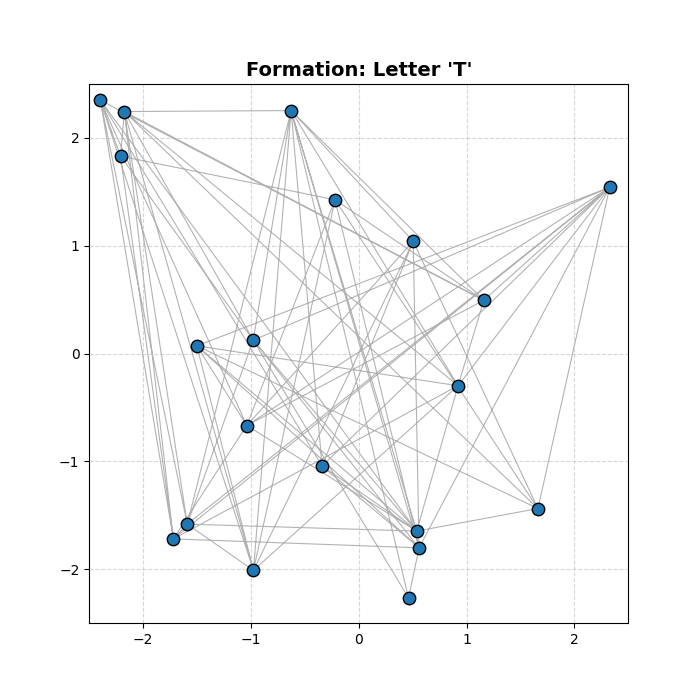

In [8]:
from IPython.display import Image
Image(filename = 'tarun_formation_control.gif')